## Business Understanding
A simple yet challenging project, to predict the housing price based on certain factors like house area, bedrooms, furnished, nearness to mainroad, etc. The dataset is small yet, it's complexity arises due to the fact that it has strong multicollinearity. Can you overcome these obstacles & build a decent predictive model?


*Objective:*
Run a predition using a linear regression model.

*Acknowledgement:*
Harrison, D. and Rubinfeld, D.L. (1978) Hedonic prices and the demand for clean air. J. Environ. Economics and Management 5, 81–102.

Belsley D.A., Kuh, E. and Welsch, R.E. (1980) Regression Diagnostics. Identifying Influential Data and Sources of Collinearity. New York: Wiley.



*Source*: [Housing Data](https://www.kaggle.com/datasets/yasserh/housing-prices-dataset)

#### Loading libraries 

In [1]:
import pandas as pd #for data manipulation and reading the data frame
from sklearn.linear_model import LinearRegression# we use sklearn as it cmposes many ML algorithms that w can use for our model
from sklearn.model_selection import train_test_split # we split the data into training and testing data
import seaborn as sns #for data visualization
from sklearn.metrics import r2_score #to check the accuracy of our model


#### Loading data

In [2]:
df = pd.read_csv("data/Housing.csv")

# **Data Understanding**

In [3]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [4]:
binary_columns =["mainroad","guestroom","basement","hotwaterheating","airconditioning"]
for col in binary_columns:
    df[col] = df[col].map({"yes":1,"no":0})

In [5]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,0,0,0,1,2,yes,furnished
1,12250000,8960,4,4,4,1,0,0,0,1,3,no,furnished
2,12250000,9960,3,2,2,1,0,1,0,0,2,yes,semi-furnished
3,12215000,7500,4,2,2,1,0,1,0,1,3,yes,furnished
4,11410000,7420,4,1,2,1,1,1,0,1,2,no,furnished


In [6]:
rows , columns = df.shape
output = f" Housing data is composed of {rows} rows and {columns} columns"
print(output)

 Housing data is composed of 545 rows and 13 columns


In [7]:
df.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='str')

In [8]:
df.info

<bound method DataFrame.info of         price  area  bedrooms  bathrooms  stories  mainroad  guestroom  \
0    13300000  7420         4          2        3         1          0   
1    12250000  8960         4          4        4         1          0   
2    12250000  9960         3          2        2         1          0   
3    12215000  7500         4          2        2         1          0   
4    11410000  7420         4          1        2         1          1   
..        ...   ...       ...        ...      ...       ...        ...   
540   1820000  3000         2          1        1         1          0   
541   1767150  2400         3          1        1         0          0   
542   1750000  3620         2          1        1         1          0   
543   1750000  2910         3          1        1         0          0   
544   1750000  3850         3          1        2         1          0   

     basement  hotwaterheating  airconditioning  parking prefarea  \
0         

In [9]:
df["area"].describe()

count      545.000000
mean      5150.541284
std       2170.141023
min       1650.000000
25%       3600.000000
50%       4600.000000
75%       6360.000000
max      16200.000000
Name: area, dtype: float64

Bi-variate analysis

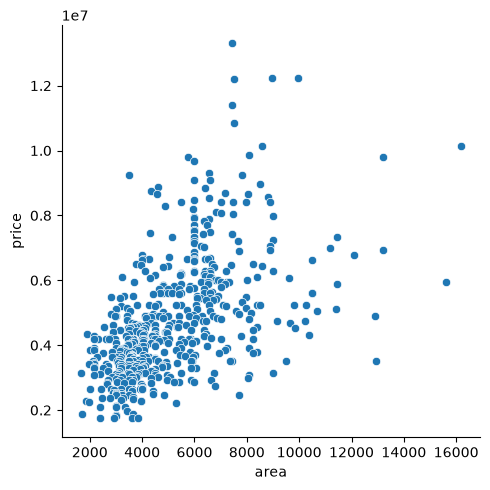

In [10]:
sns.relplot(data=df, x="area", y="price")

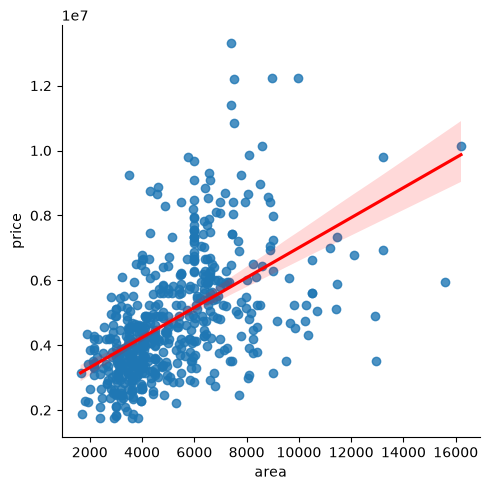

In [11]:
sns.lmplot(data=df, x="area", y="price", line_kws={"color":"red"})

Findings:
- The data set is likely non-linear in nature (im-plying there is possibility of them not being related)

In [12]:
df.describe

<bound method NDFrame.describe of         price  area  bedrooms  bathrooms  stories  mainroad  guestroom  \
0    13300000  7420         4          2        3         1          0   
1    12250000  8960         4          4        4         1          0   
2    12250000  9960         3          2        2         1          0   
3    12215000  7500         4          2        2         1          0   
4    11410000  7420         4          1        2         1          1   
..        ...   ...       ...        ...      ...       ...        ...   
540   1820000  3000         2          1        1         1          0   
541   1767150  2400         3          1        1         0          0   
542   1750000  3620         2          1        1         1          0   
543   1750000  2910         3          1        1         0          0   
544   1750000  3850         3          1        2         1          0   

     basement  hotwaterheating  airconditioning  parking prefarea  \
0       

In [13]:
df.describe(include ="object") #caputres non - numerical columns 

C:\Users\USER\AppData\Local\Temp\ipykernel_7124\2871464579.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include ="object") #caputres non - numerical columns


,prefarea,furnishingstatus
count,545,545
unique,2,3
top,no,semi-furnished
freq,417,227


# **Data preparation**

Note:
we are dealing with a simple linear regression problem , target variable is *price* and independent variable is *'area'*

In [14]:
df_2 = df[['price','area']]#picking the columns we want to use for our model
df_2.head()

,price,area
0,13300000,7420
1,12250000,8960
2,12250000,9960
3,12215000,7500
4,11410000,7420


# **Modelling**

In [15]:
x = df_2[['area']]
y = df_2['price']



spitting our data for modelling:
- trainig data is data that we let the model learn about or rather expose to model
- our data size is small hence splitting to the ratio 80:20 is not ideal we split it 70:30
Test data 
- i sdat we expose to the model to allow it to generate answer and based on them we compare them with the test answers

In [16]:
x_train,x_test,y_train,y_test = train_test_split(x, y , test_size=38, random_state=42)
"""
random state => matheatical formular that retaiins the sequece of number selection in a set of numbers. It is used to ensure that the same random numbers are generated each time the code is run, which can be useful for reproducibility and debugging.
"""

'\nrandom state => matheatical formular that retaiins the sequece of number selection in a set of numbers. It is used to ensure that the same random numbers are generated each time the code is run, which can be useful for reproducibility and debugging.\n'

In [17]:
regressor = LinearRegression()#creates an instance of the linear regression model and assigns it to the variabl

In [18]:
linear_reg_model.fit(x_train, y_train)

NameError: name 'linear_reg_model' is not defined

In [ ]:
regressor.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[439.63]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['area']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.511e+06
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,1


In [ ]:
y_predicted = regressor.predict(x_test)

In [ ]:
y_predicted

array([5105249.47532304, 5369026.27231272, 4287541.40465503,
       4709584.27983852, 4252371.1650564 , 5465744.43120894,
       6257074.82217799, 4705187.99988869, 3935839.00866878,
       3698439.89137807, 6283452.50187695, 4240940.83718685,
       4146860.44626053, 3874291.08937119, 4256767.44500623,
       4107293.92671208, 3390700.29489011, 5149212.27482132,
       5083268.0755739 , 5149212.27482132, 4718376.83973817,
       5511905.37068213, 4115646.85861675, 4182030.68585915,
       6138375.26353263, 6890139.13495322, 3869894.80942136,
       3830328.28987291, 8314533.83869751, 3830328.28987291,
       4269956.28485571, 3883083.64927085, 5149212.27482132,
       5419583.49173575, 4610667.98096739, 4533733.0818454 ,
       4553955.96961461, 3909461.32896982])

## **Evaluation**

In [ ]:
r2_score(y_test, y_predicted)

0.4263122964525745

## **Deployment**